# Student Performance Prediction — Exploratory Data Analysis (Phase 5)

**Dataset:** UCI Student Performance (Math course), cleaned in Phase 4
(`Dataset/student-mat.csv` raw + `Dataset/student_mat_cleaned.csv` modeling-ready).

**Scope note:** `G1`/`G2` (prior period grades) are excluded from this project
by deliberate design choice (see `Documentation/decision.md`, D-006), so this
EDA focuses on the remaining "leading" indicators as predictors of `G3`.

This notebook performs univariate, bivariate, and correlation analysis with
insight notes after every visualization, per the project's EDA requirements.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

raw = pd.read_csv('../Dataset/student-mat.csv', sep=';')
# Outlier-capped absences (matches Phase 4 cleaning) for consistent EDA
q1, q3 = raw['absences'].quantile([0.25, 0.75])
upper = q3 + 1.5*(q3-q1)
raw['absences_capped'] = raw['absences'].clip(upper=upper)

df = raw.drop(columns=['G1', 'G2'])  # excluded per D-006
df.shape


(395, 32)

## 1. Target Variable Distribution — `G3` (Final Grade, 0–20)

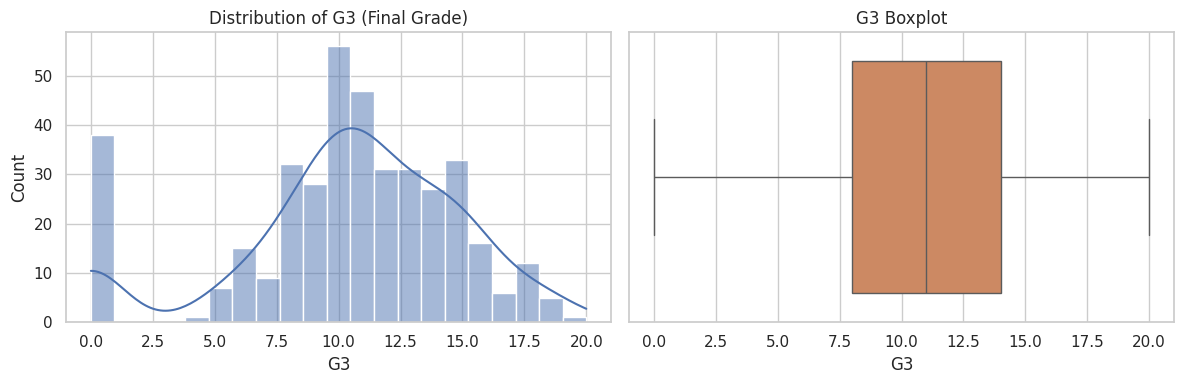

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

Students with G3 = 0: 38 (9.6%)


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['G3'], bins=21, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of G3 (Final Grade)')
axes[0].set_xlabel('G3')

sns.boxplot(x=df['G3'], ax=axes[1], color='#DD8452')
axes[1].set_title('G3 Boxplot')
plt.tight_layout()
plt.savefig('figures/01_target_distribution.png', bbox_inches='tight')
plt.show()

print(df['G3'].describe())
print('\nStudents with G3 = 0:', (df['G3']==0).sum(), f"({(df['G3']==0).mean()*100:.1f}%)")


**Insight:** `G3` is roughly bell-shaped and centered around 10–11 (out of 20),
with a visible spike of 0s (≈9.6% of students — per Phase 3, these are
students who likely did not sit the final exam rather than data errors). This
spike means the target isn't perfectly normal, which is worth keeping in mind
when interpreting residuals later — a few models may systematically
under/over-predict this "zero" subgroup.

## 2. Univariate Analysis — Key Numeric Features

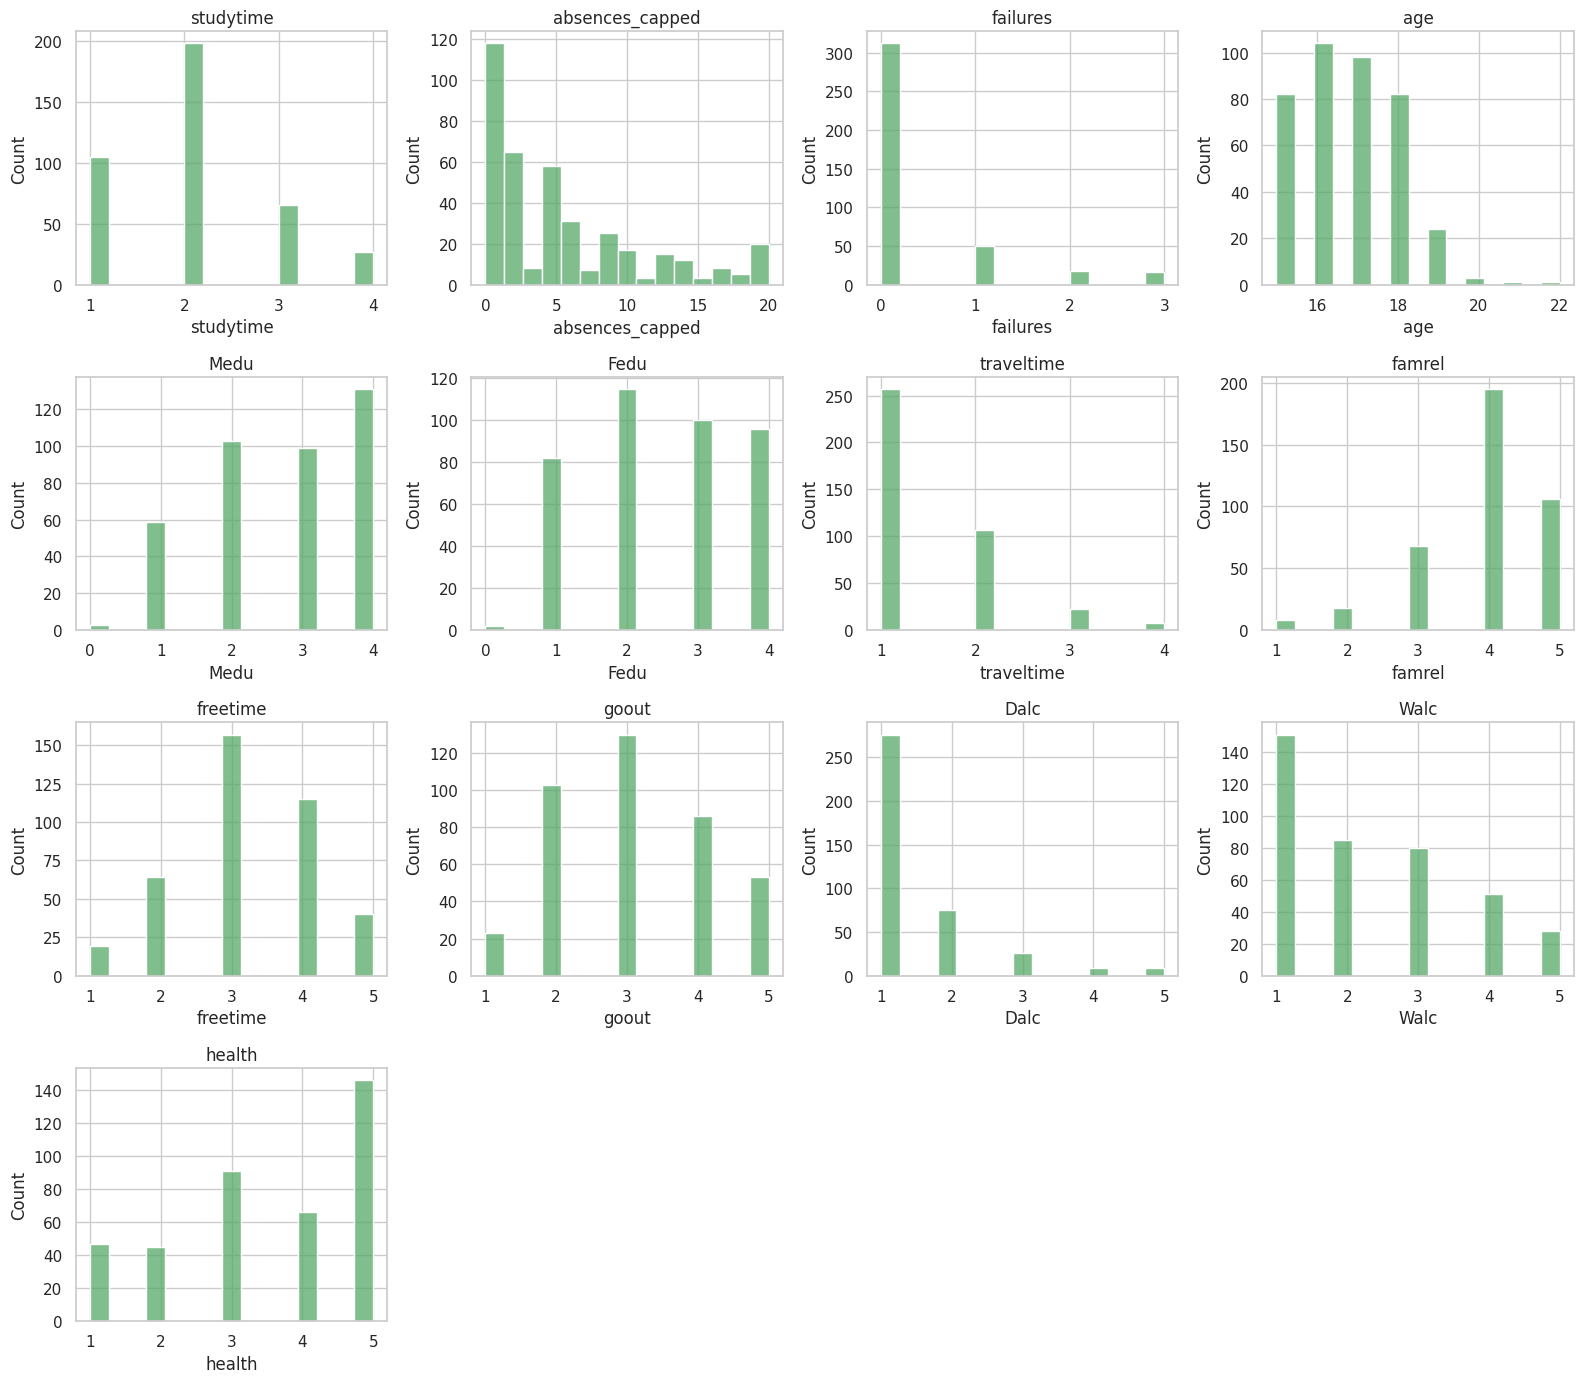

In [3]:
numeric_feats = ['studytime', 'absences_capped', 'failures', 'age',
                  'Medu', 'Fedu', 'traveltime', 'famrel', 'freetime',
                  'goout', 'Dalc', 'Walc', 'health']

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_feats):
    sns.histplot(df[col], bins=15, ax=axes[i], color='#55A868')
    axes[i].set_title(col)
for j in range(len(numeric_feats), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('figures/02_univariate_numeric.png', bbox_inches='tight')
plt.show()


**Insight:** `failures` is extremely skewed — the large majority of students
have 0 prior failures, with a long tail of 1–3. `studytime` is concentrated at
levels 1–2 (i.e., 0–5 hours/week), with very few students studying 10+
hours/week (level 4). `Dalc` (workday alcohol use) is heavily skewed toward
"very low," while `Walc` (weekend alcohol use) is more spread out — a
behavioral difference worth carrying into feature engineering.

## 3. Target Distribution by Key Categorical Features

/tmp/ipykernel_557/127385948.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='G3', ax=axes[i], palette='Set2')
/tmp/ipykernel_557/127385948.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='G3', ax=axes[i], palette='Set2')
/tmp/ipykernel_557/127385948.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='G3', ax=axes[i], palette='Set2')
/tmp/ipykernel_557/127385948.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign t

/tmp/ipykernel_557/127385948.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='G3', ax=axes[i], palette='Set2')
/tmp/ipykernel_557/127385948.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='G3', ax=axes[i], palette='Set2')


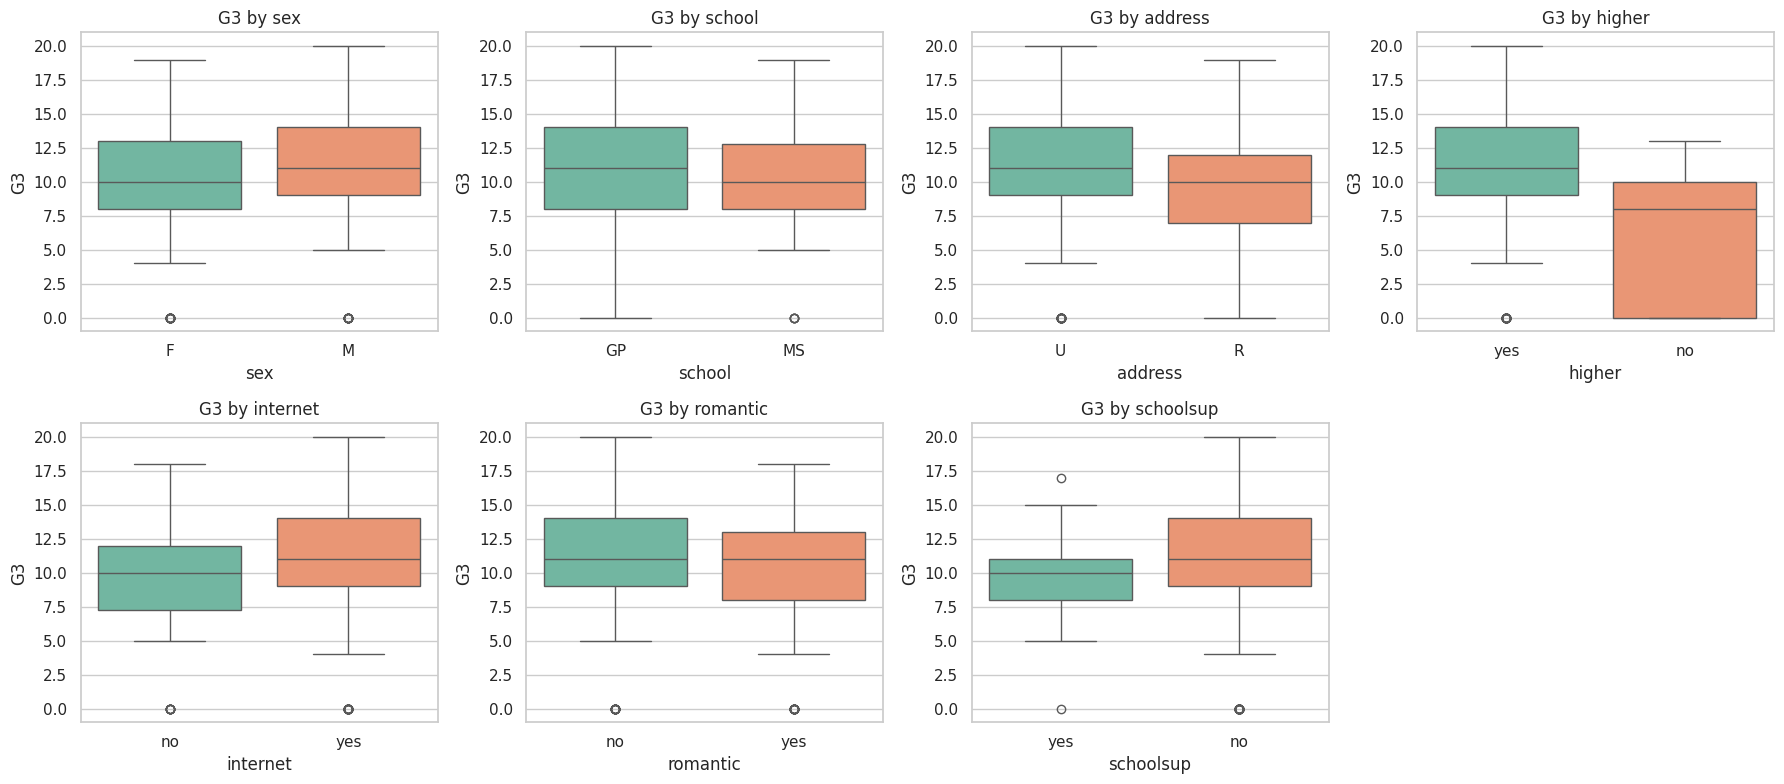

sex
F     9.97
M    10.91
Name: G3, dtype: float64 

school
GP    10.49
MS     9.85
Name: G3, dtype: float64 

address
R     9.51
U    10.67
Name: G3, dtype: float64 

higher
no      6.80
yes    10.61
Name: G3, dtype: float64 

internet
no      9.41
yes    10.62
Name: G3, dtype: float64 

romantic
no     10.84
yes     9.58
Name: G3, dtype: float64 

schoolsup
no     10.56
yes     9.43
Name: G3, dtype: float64 



In [4]:
cat_feats = ['sex', 'school', 'address', 'higher', 'internet', 'romantic', 'schoolsup']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(cat_feats):
    sns.boxplot(data=df, x=col, y='G3', ax=axes[i], palette='Set2')
    axes[i].set_title(f'G3 by {col}')
fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig('figures/03_target_by_categorical.png', bbox_inches='tight')
plt.show()

for col in cat_feats:
    print(df.groupby(col)['G3'].mean().round(2), '\n')


**Insight:** The clearest categorical signal is `higher` (whether the
student wants to pursue higher education) — students who do average
noticeably higher `G3` than those who don't. `schoolsup` (school educational
support) shows *lower* average G3 for supported students, which likely
reflects that support is targeted at already-struggling students rather than
support causing worse outcomes (an important causal caveat to state explicitly
in the report). Differences by `sex`, `address`, and `internet` are present
but comparatively small.

## 4. Bivariate Analysis — Numeric Features vs `G3`

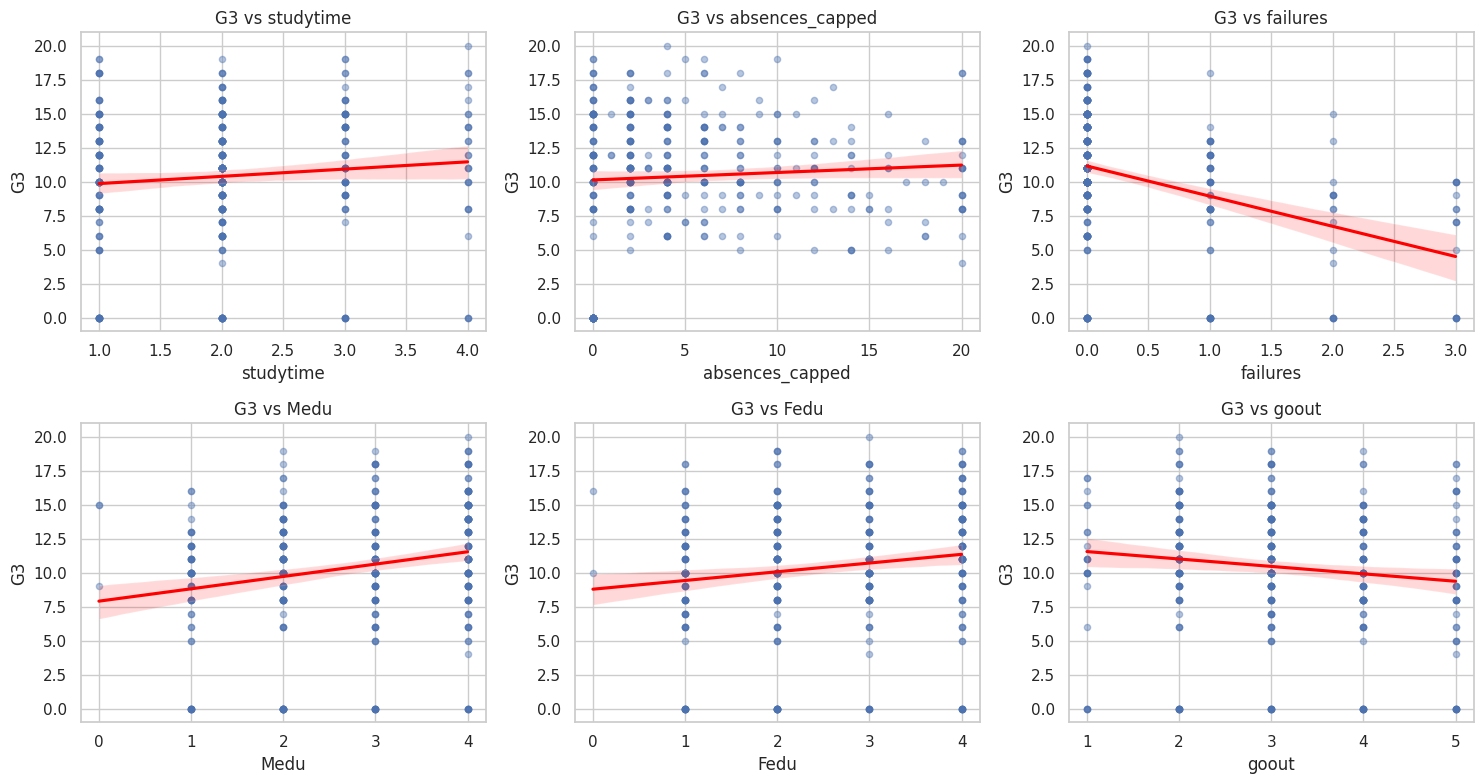

In [5]:
scatter_feats = ['studytime', 'absences_capped', 'failures', 'Medu', 'Fedu', 'goout']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(scatter_feats):
    sns.regplot(data=df, x=col, y='G3', ax=axes[i],
                scatter_kws={'alpha':0.4, 's':20}, line_kws={'color':'red'})
    axes[i].set_title(f'G3 vs {col}')
plt.tight_layout()
plt.savefig('figures/04_bivariate_scatter.png', bbox_inches='tight')
plt.show()


**Insight:** `failures` shows the clearest negative linear trend with
`G3` (consistent with the Phase 3 correlation of r=-0.36) — each additional
past class failure is associated with a meaningfully lower final grade.
`studytime` shows a weak positive trend, `Medu`/`Fedu` (parental education)
show mild positive trends, and `goout` (going out with friends) shows a mild
negative trend. `absences_capped` shows almost no visible linear relationship
with `G3` at this scale — consistent with its very low correlation (r=0.03).

## 5. Correlation Analysis

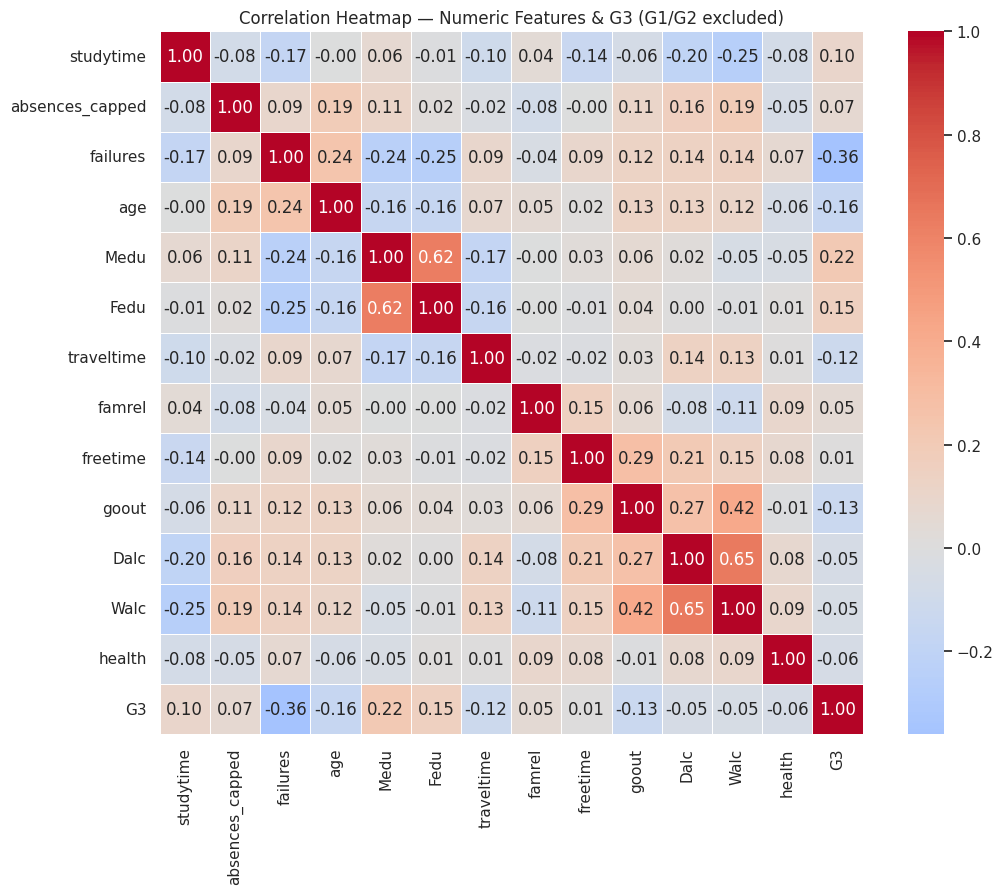

G3                 1.000000
Medu               0.217147
Fedu               0.152457
studytime          0.097820
absences_capped    0.068030
famrel             0.051363
freetime           0.011307
Walc              -0.051939
Dalc              -0.054660
health            -0.061335
traveltime        -0.117142
goout             -0.132791
age               -0.161579
failures          -0.360415
Name: G3, dtype: float64

In [6]:
corr_cols = numeric_feats + ['G3']
corr = df[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features & G3 (G1/G2 excluded)')
plt.tight_layout()
plt.savefig('figures/05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

corr['G3'].sort_values(ascending=False)


**Insight:** With `G1`/`G2` excluded, no single feature is strongly
correlated with `G3` — the strongest is `failures` (≈ -0.36), everything else
is weak (|r| < 0.25). This confirms the modeling framing choice from D-006:
predicting final grade from purely "leading" indicators is a genuinely harder
problem than predicting from prior grades, and no single-feature shortcut
exists — the model will need to combine many weak signals. Also notable:
`Dalc` and `Walc` (workday/weekend alcohol use) are strongly correlated with
each other (~0.6-0.7, expected) but only weakly with `G3` directly.

## 6. Outlier Visualization — `absences` (Before vs After Capping)

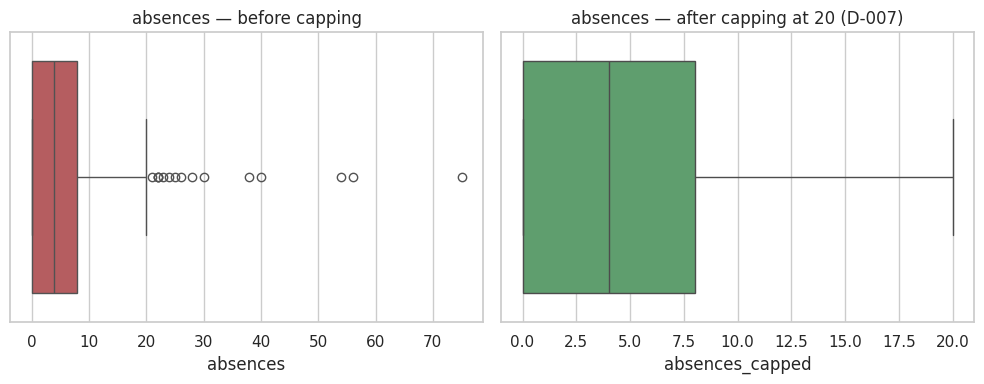

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(x=raw['absences'], ax=axes[0], color='#C44E52')
axes[0].set_title('absences — before capping')
sns.boxplot(x=raw['absences_capped'], ax=axes[1], color='#55A868')
axes[1].set_title('absences — after capping at 20 (D-007)')
plt.tight_layout()
plt.savefig('figures/06_absences_outliers.png', bbox_inches='tight')
plt.show()


**Insight:** The capping applied in Phase 4 (decision D-007) visibly
tightens the distribution while preserving all 395 records — the pre-cap
boxplot shows several extreme points out to 75 days absent, which would have
disproportionately influenced any distance- or gradient-based model.

## 7. EDA Summary — Key Takeaways for Feature Engineering (Phase 6)

1. **`failures` is the single strongest available predictor** of `G3` in this
   G1/G2-excluded framing — worth considering interaction terms with it.
2. **`studytime`, `Medu`, `Fedu`, `goout`** all show weak-but-real trends and
   should be retained; combining `Medu`+`Fedu` into a "parental education"
   composite is worth testing in Phase 6.
3. **`absences_capped`** shows minimal linear relationship with `G3` at this
   granularity — its predictive value may only emerge in combination with
   other features (e.g., interaction with `studytime`) or through non-linear
   models (Random Forest / Gradient Boosting / XGBoost) rather than linear ones.
4. **`higher` (aspiration to pursue higher education)** is the strongest
   categorical signal found — a simple but meaningful feature to keep.
5. **`schoolsup`'s negative association with G3 is confounded**, not causal —
   must be stated explicitly in the report to avoid a misleading claim.
6. **No missing values, no duplicates, outliers handled** — the dataset is
   ready for Phase 6 (Feature Engineering) and Phase 7 (Model Development).
